<a href="https://colab.research.google.com/github/jesicaroman17-cpu/Intro_ciencia-datos-JR/blob/main/Trabajo_Final_Ciencia_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('/content/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
df.shape

(32581, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


Se realizó la clasificación y tipificación de las variables del conjunto de datos. Las variables person_home_ownership, loan_intent y cb_person_default_on_file fueron definidas como variables categóricas nominales, mientras que loan_grade fue tratada como una variable categórica ordinal debido a la jerarquía implícita de los grados de riesgo crediticio. La variable loan_status se conservó como variable binaria objetivo para la construcción del modelo predictivo.

In [4]:
# se convierten las variables categoricas a categoricas
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'cb_person_default_on_file'
]
df[cat_cols] = df[cat_cols].astype('category')

In [5]:
#Variable categorica ordinal
orden_grado = [
    'A',
    'B',
    'C',
    'D',
    'E',
    'F',
    'G'
]
df['loan_grade'] = pd.Categorical(df['loan_grade'], categories=orden_grado, ordered=True)

El conjunto de datos contiene 32.581 observaciones y 12 variables relacionadas con las características demográficas, laborales y financieras de solicitantes de crédito. La variable objetivo corresponde al estado del préstamo (loan_status), donde 0 representa clientes sin incumplimiento y 1 clientes que incurrieron en incumplimiento. Durante la revisión inicial se identificaron variables numéricas y categóricas, así como la presencia de valores faltantes en las variables person_emp_length y loan_int_rate. Adicionalmente, se observaron registros potencialmente inconsistentes que deberán evaluarse durante el proceso de depuración y análisis exploratorio.

In [6]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
loan_int_rate,9.563856
person_emp_length,2.747000
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


Se identificaron valores faltantes únicamente en las variables loan_int_rate (9,56%) y person_emp_length (2,75%). El resto de las variables presentan información completa. Dado que los porcentajes de ausencia son relativamente bajos y ninguna variable supera el 10% de registros faltantes, inicialmente se considera viable aplicar técnicas de imputación en lugar de eliminar observaciones o variables. La estrategia definitiva será definida posteriormente tras analizar la distribución y comportamiento de estas variables.

In [7]:
df.duplicated().sum()

np.int64(165)

Se identificaron 165 registros duplicados, equivalentes al 0,51% del conjunto de datos. Debido a que los registros fueron identificados como duplicados considerando la totalidad de las variables disponibles y representan una proporción reducida de la base, se decidió conservar únicamente la primera ocurrencia de cada observación para evitar posibles sesgos en los análisis posteriores.

In [8]:
# Eliminación de duplicados
df1 = df.drop_duplicates()
df1.shape

(32416, 12)

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32416 non-null  int64   
 1   person_income               32416 non-null  int64   
 2   person_home_ownership       32416 non-null  category
 3   person_emp_length           31529 non-null  float64 
 4   loan_intent                 32416 non-null  category
 5   loan_grade                  32416 non-null  category
 6   loan_amnt                   32416 non-null  int64   
 7   loan_int_rate               29321 non-null  float64 
 8   loan_status                 32416 non-null  int64   
 9   loan_percent_income         32416 non-null  float64 
 10  cb_person_default_on_file   32416 non-null  category
 11  cb_person_cred_hist_length  32416 non-null  int64   
dtypes: category(4), float64(3), int64(5)
memory usage: 2.4 MB


In [10]:
df1['loan_status'].value_counts(normalize=True)*100

#Equivalencia a SQL
"""
SELECT
    loan_status,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS porcentaje
FROM credit_risk
GROUP BY loan_status
"""

'\nSELECT\n    loan_status,\n    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS porcentaje\nFROM credit_risk\nGROUP BY loan_status\n'

Aunque la mayoría de los créditos no presentan incumplimiento, la proporción de clientes que sí incumplen no es despreciable, ya que cerca de 22% de préstamos termina en default. Esto justifica la necesidad de desarrollar modelos predictivos que permitan identificar tempranamente clientes con mayor riesgo crediticio.

In [11]:
# Análisis variables categóricas
for col in [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file']:

    print(f"\n{'='*60}")

    tabla = pd.DataFrame({
        'Cantidad': df1[col].value_counts(),
        'Porcentaje (%)': round(df1[col].value_counts(normalize=True) * 100,2)
    })

    print(tabla)


                       Cantidad  Porcentaje (%)
person_home_ownership                          
RENT                      16378           50.52
MORTGAGE                  13369           41.24
OWN                        2563            7.91
OTHER                       106            0.33

                   Cantidad  Porcentaje (%)
loan_intent                                
EDUCATION              6411           19.78
MEDICAL                6042           18.64
VENTURE                5682           17.53
PERSONAL               5498           16.96
DEBTCONSOLIDATION      5189           16.01
HOMEIMPROVEMENT        3594           11.09

            Cantidad  Porcentaje (%)
loan_grade                          
A              10703           33.02
B              10387           32.04
C               6438           19.86
D               3620           11.17
E                963            2.97
F                241            0.74
G                 64            0.20

                       

La cartera analizada está compuesta principalmente por solicitantes que viven en viviendas arrendadas (50,52%) o que poseen una vivienda hipotecada (41,24%), mientras que únicamente el 7,91% corresponde a propietarios sin obligaciones hipotecarias. Esta distribución sugiere una alta participación de individuos que aún se encuentran en proceso de consolidación patrimonial.

Los créditos son solicitados principalmente para fines educativos (19,78%) y médicos (18,64%), seguidos por emprendimiento (17,53%) y necesidades personales (16,96%). Por el contrario, las solicitudes destinadas a mejoras del hogar representan la menor proporción de la cartera (11,09%).

La calidad crediticia de los préstamos se concentra principalmente en las categorías A (33,02%) y B (32,04%), las cuales corresponden a perfiles de menor riesgo. En contraste, las categorías de mayor riesgo (E, F y G) representan únicamente el 3,91% de los créditos analizados, lo que evidencia una cartera predominantemente compuesta por clientes con perfiles crediticios favorables.

Respecto al historial de incumplimiento, el 82,32% de los solicitantes no presenta antecedentes de default, mientras que el 17,68% registra eventos de incumplimiento previos. Este último grupo constituye un segmento de especial interés para el análisis, dado que podría estar asociado a una mayor probabilidad de incumplimiento futuro.

In [12]:
df1.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000


Las variables numéricas presentan comportamientos razonables en términos generales. Sin embargo, se identificaron posibles inconsistencias en la edad máxima (144 años), la antigüedad laboral máxima (123 años) y algunos ingresos excepcionalmente altos, por lo que se realizará una revisión detallada de valores atípicos y reglas de negocio.

In [13]:
df1[['person_age',
     'person_income',
     'person_emp_length',
     'loan_amnt',
     'loan_int_rate',
     'loan_percent_income',
     'cb_person_cred_hist_length']].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,2.000000
1%,21.000000,1.440000e+04,0.00000,1000.000000,5.420000,0.020000,2.000000
5%,22.000000,2.293200e+04,0.00000,2000.000000,6.030000,0.040000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.230000,8.000000
95%,40.000000,1.380000e+05,13.00000,24000.000000,16.320000,0.380000,14.000000


El análisis de percentiles permitió confirmar la presencia de valores extremos en las **variables edad, ingreso anual y antiguedad laboral**. Particularmente, el percentil 99 de edad corresponde a 50 años, mientras que se observan registros de hasta 144 años. De igual manera, el 99% de los solicitantes presenta ingresos inferiores a 225.000, aunque existen casos que alcanzan 6.000.000. Estos hallazgos motivaron una revisión específica de registros potencialmente inconsistentes.

In [14]:
df1[df1['person_age'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [15]:
df1[df1['person_emp_length'] > df1['person_age']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


Validación de reglas de negocio

Reglas aplicadas:
* Edad ≤ 100 años.
* Antigüedad laboral ≤ Edad.

Se identificaron registros con edades superiores a 100 años y casos en los que la antigüedad laboral superaba la edad del solicitante. Debido a que estas observaciones contradicen reglas básicas del negocio y representan una proporción mínima del conjunto de datos, se decidió eliminarlas para mejorar la calidad de la información analizada.

In [16]:
df2 = df1.copy()

df2 = df2[(df2['person_age'] <= 100)&(df2['person_emp_length'].isna()|(df2['person_emp_length'] <= df2['person_age']))]
df2.shape

(32409, 12)

## **Tratamiento de datos faltantes**

La variable person_emp_length presentaba un 2,75% de valores faltantes. Debido a la presencia de valores extremos en la distribución, se imputaron los registros faltantes utilizando la mediana de la variable.

Por su parte, loan_int_rate registraba un 9,56% de valores faltantes. Dado que la tasa de interés está estrechamente relacionada con la calificación crediticia (loan_grade), se decidió imputar los valores faltantes utilizando la mediana de la tasa dentro de cada categoría de riesgo. Esta estrategia permite conservar de mejor manera el comportamiento esperado de la variable y reducir posibles sesgos.

In [17]:
# Antigüedad laboral
df2['person_emp_length'] = (
    df2['person_emp_length']
    .fillna(
        df2['person_emp_length'].median()
    )
)

# Tasa de interés
df2['loan_int_rate'] = (
    df2.groupby('loan_grade')['loan_int_rate']
       .transform(
           lambda x: x.fillna(
               x.median()
           )
       )
)

/tmp/ipykernel_1009/3315565014.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby('loan_grade')['loan_int_rate']


### Analisis sobre la variable de ingreso anual:

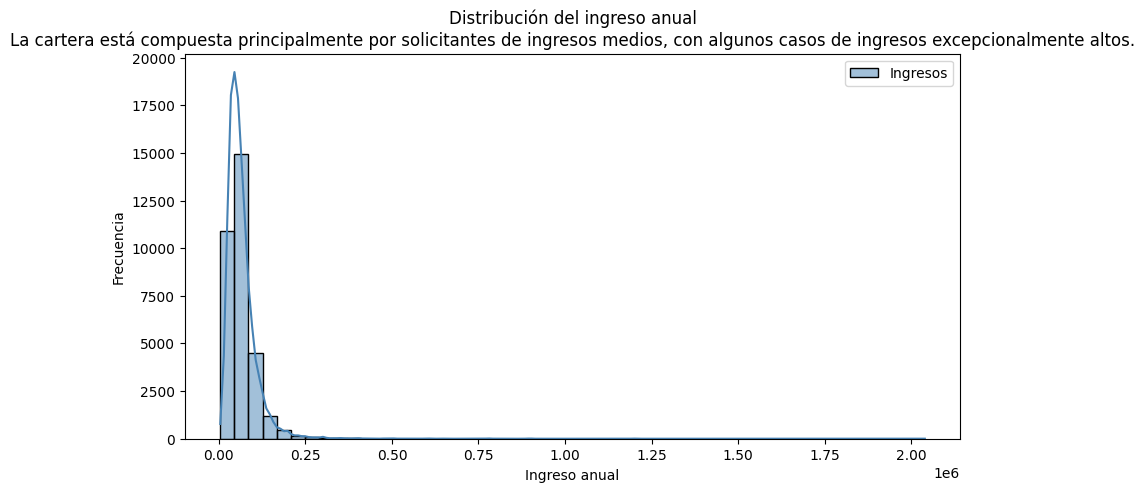

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    data=df2,
    x='person_income',
    bins=50,
    kde=True,
    color='steelblue',
    label='Ingresos'
)

plt.title(
    'Distribución del ingreso anual\n'
    'La cartera está compuesta principalmente por solicitantes de ingresos medios, con algunos casos de ingresos excepcionalmente altos.'
)

plt.xlabel('Ingreso anual')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

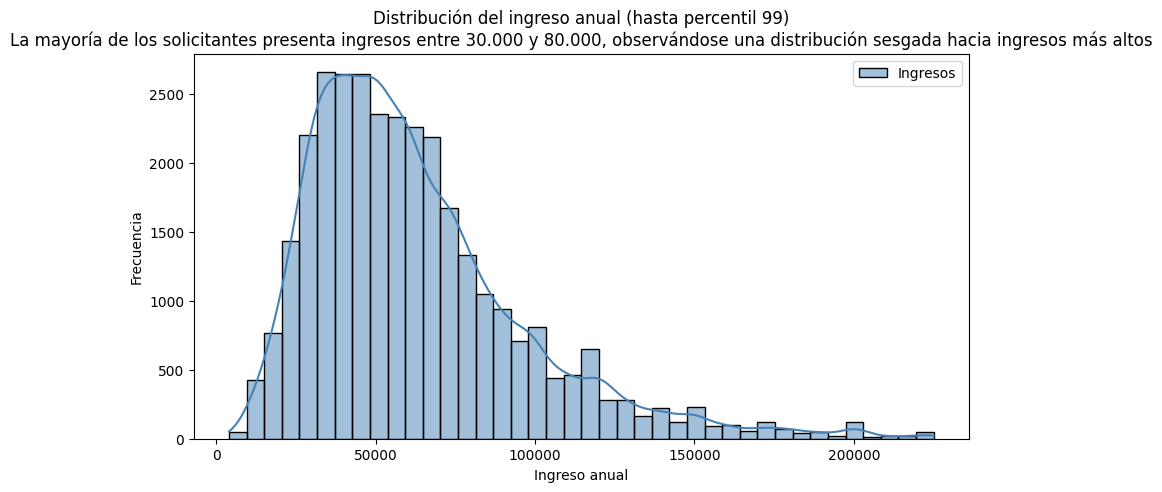

In [19]:
p99 = df2['person_income'].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(
    data=df2[df2['person_income'] <= p99],
    x='person_income',
    bins=40,
    kde=True,
    color='steelblue',
    label='Ingresos'
)

plt.title(
    'Distribución del ingreso anual (hasta percentil 99)\n'
    'La mayoría de los solicitantes presenta ingresos entre 30.000 y 80.000, observándose una distribución sesgada hacia ingresos más altos'
)

plt.xlabel('Ingreso anual')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

La mayoría de los solicitantes presenta ingresos entre 30.000 y 80.000, observándose una distribución asimétrica hacia la derecha debido a la presencia de clientes con ingresos superiores al promedio.

## **Relación entre las variables y el incumplimiento crediticio**

In [20]:
round(pd.crosstab(df2['cb_person_default_on_file'], df2['loan_status'], normalize='index') * 100, 2)

loan_status,0,1
cb_person_default_on_file,,
N,81.56,18.44
Y,62.14,37.86


El historial de incumplimiento previo constituye uno de los factores de riesgo más relevantes dentro del conjunto de datos. Mientras que los clientes sin antecedentes presentan una tasa de incumplimiento del 18,44%, aquellos que registran defaults previos alcanzan una tasa de incumplimiento del 37,86%. Esto sugiere que el comportamiento crediticio pasado es un fuerte indicador del riesgo futuro.

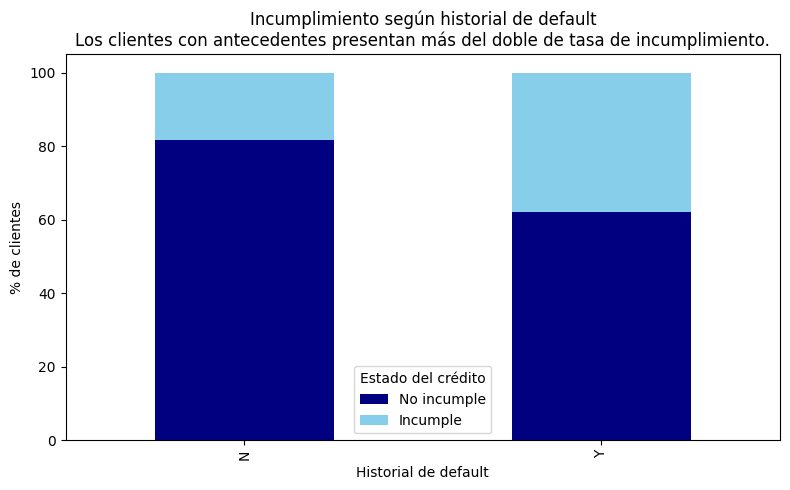

In [21]:
tabla_default = round(pd.crosstab(df2['cb_person_default_on_file'], df2['loan_status'], normalize='index') * 100, 2)

tabla_default.plot(kind='bar', stacked=True, figsize=(8,5), color=['#000080', '#87CEEB'])

plt.title(
    'Incumplimiento según historial de default\n'
    'Los clientes con antecedentes presentan más del doble de tasa de incumplimiento.'
)

plt.xlabel('Historial de default')
plt.ylabel('% de clientes')
plt.legend(
    ['No incumple', 'Incumple'],
    title='Estado del crédito'
)

plt.tight_layout()
plt.show()

In [22]:
tabla_grade = round(pd.crosstab(df2['loan_grade'], df2['loan_status'], normalize='index') * 100,2)
tabla_grade

loan_status,0,1
loan_grade,,
A,90.04,9.96
B,83.68,16.32
C,79.24,20.76
D,40.95,59.05
E,35.51,64.49
F,29.46,70.54
G,1.56,98.44


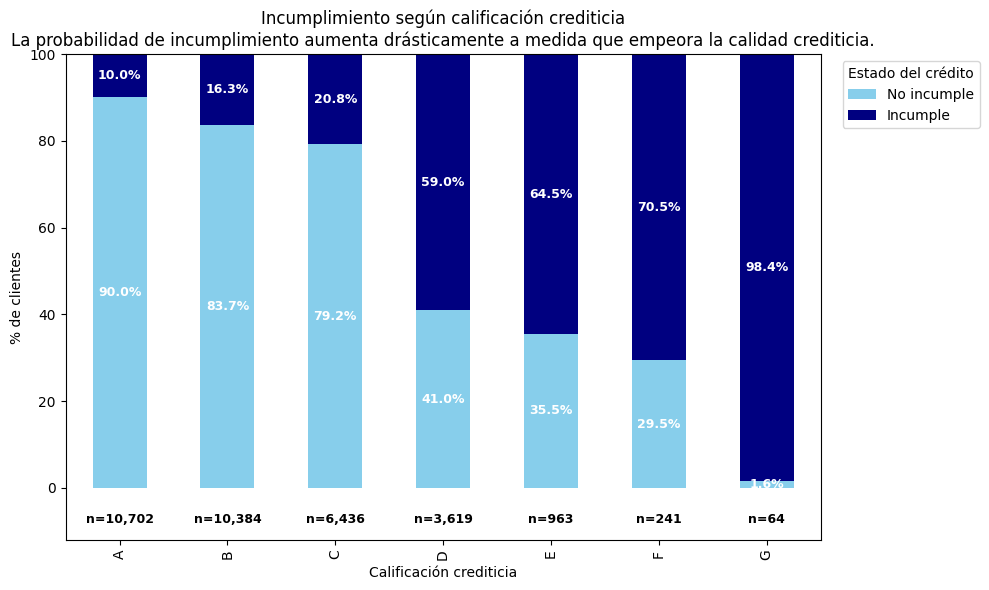

In [36]:
# Cantidades por grade (para mostrarlas debajo)
n_por_grade = df2['loan_grade'].value_counts().sort_index()

ax = tabla_grade.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#87CEEB', '#000080']
)

# Porcentajes dentro de las barras
for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.1f%%',
        label_type='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

# Agregar tamaño poblacional debajo de cada categoría
for i, (grade, n) in enumerate(n_por_grade.items()):
    ax.text(
        i,
        -8,
        f'n={n:,}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Incumplimiento según calificación crediticia\n'
    'La probabilidad de incumplimiento aumenta drásticamente a medida que empeora la calidad crediticia.',
    fontsize=12
)

plt.xlabel('Calificación crediticia')
plt.ylabel('% de clientes')

# Mover leyenda fuera de la gráfica
plt.legend(
    ['No incumple', 'Incumple'],
    title='Estado del crédito',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Espacio adicional para los tamaños poblacionales
plt.ylim(-12, 100)

plt.tight_layout()

plt.show()

La calificación crediticia es el factor con mayor capacidad explicativa observado hasta el momento. A medida que la calidad crediticia se deteriora, la tasa de incumplimiento aumenta de forma significativa, pasando de 9,96% para los créditos clasificados como A a 98,44% para los créditos clasificados como G. Este comportamiento evidencia una relación directa entre el nivel de riesgo asignado al cliente y la probabilidad de incumplimiento del crédito.


/tmp/ipykernel_1009/1152321026.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='loan_status', y='loan_percent_income', palette=['#87CEEB', '#DC143C'])


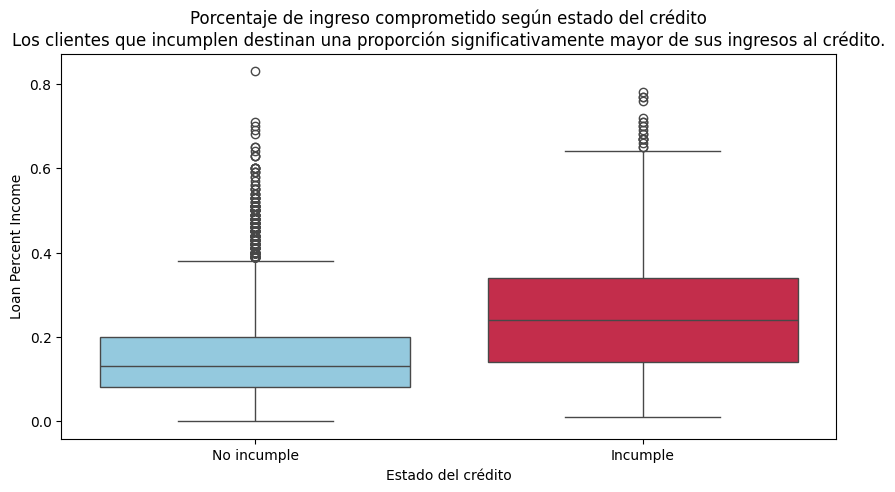

In [24]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df2, x='loan_status', y='loan_percent_income', palette=['#87CEEB', '#DC143C'])

plt.title(
    'Porcentaje de ingreso comprometido según estado del crédito\n'
    'Los clientes que incumplen destinan una proporción significativamente mayor de sus ingresos al crédito.'
)

plt.xlabel('Estado del crédito')
plt.ylabel('Loan Percent Income')

plt.xticks(
    [0,1],
    ['No incumple','Incumple']
)

plt.show()

In [25]:
df2.groupby('loan_status')['loan_percent_income'].agg(['mean','median'])

#Equivalendia a SQL
"""
SELECT
    loan_status,
    AVG(loan_percent_income) AS promedio,
    PERCENTILE_CONT(0.5)
        WITHIN GROUP (ORDER BY loan_percent_income) AS mediana
FROM credit_risk
GROUP BY loan_status
"""

'\nSELECT\n    loan_status,\n    AVG(loan_percent_income) AS promedio,\n    PERCENTILE_CONT(0.5)\n        WITHIN GROUP (ORDER BY loan_percent_income) AS mediana\nFROM credit_risk\nGROUP BY loan_status\n'

El porcentaje del ingreso comprometido por el préstamo muestra una relación clara con el incumplimiento crediticio. Los clientes que incumplen destinan en promedio el 24,7% de sus ingresos al pago del crédito, mientras que los clientes que cumplen destinan aproximadamente el 14,9%. Esta diferencia también se refleja en la mediana (24% frente a 13%), lo que sugiere que una mayor carga financiera podría estar asociada con un incremento en la probabilidad de incumplimiento.

In [26]:
tabla_intent = round(pd.crosstab(df2['loan_intent'], df2['loan_status'], normalize='index') * 100, 2)
tabla_intent

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,71.32,28.68
EDUCATION,82.74,17.26
HOMEIMPROVEMENT,73.85,26.15
MEDICAL,73.24,26.76
PERSONAL,80.11,19.89
VENTURE,85.14,14.86


La finalidad del crédito parece estar asociada con el riesgo de incumplimiento. Los préstamos destinados a consolidación de deuda (28,68%) y gastos médicos (26,76%) registran las mayores tasas de incumplimiento, mientras que aquellos orientados a emprendimiento (14,86%) y educación (17,26%) presentan los niveles más bajos. Esto podría indicar que los créditos asociados a necesidades financieras o eventos imprevistos conllevan un mayor riesgo que aquellos orientados a inversión o formación.

In [27]:
tabla_home = round(pd.crosstab(df2['person_home_ownership'], df2['loan_status'],normalize='index') * 100,2)
tabla_home

loan_status,0,1
person_home_ownership,,
MORTGAGE,87.38,12.62
OTHER,68.87,31.13
OWN,92.51,7.49
RENT,68.39,31.61


El tipo de vivienda evidencia una relación importante con el incumplimiento crediticio. Los solicitantes propietarios de su vivienda presentan las menores tasas de default (7,49%), mientras que los clientes que viven en inmuebles arrendados alcanzan niveles de incumplimiento superiores al 31%. Este comportamiento podría reflejar diferencias en estabilidad financiera y capacidad patrimonial entre los distintos grupos.

# **Feature Engineering (Creación de Variables)**

Con el fin de enriquecer el análisis y capturar patrones que no son evidentes en las variables originales, se construyeron nuevas variables a partir de transformaciones, agrupaciones y reglas de negocio. Estas variables permitirán evaluar de una forma más sencilla factores asociados al riesgo crediticio, tales como la edad, la capacidad de pago, el historial crediticio y el nivel de endeudamiento.

In [28]:
import numpy as np
import pandas as pd

# ==================================================
# Variables derivadas de la edad
# ==================================================

df2['grupo_edad'] = pd.cut(df2['person_age'], bins=[0,25,35,50,100], labels=['18-25','26-35','36-50','50+'], include_lowest=True)

# ==================================================
# Variables derivadas del ingreso
# ==================================================

df2['grupo_ingreso'] = pd.qcut(df2['person_income'], q=4, labels=['Bajo', 'Medio', 'Alto', 'Muy Alto'])

# Transformación logarítmica para reducir asimetría
df2['log_income'] = np.log1p(df2['person_income'])

# ==================================================
# Variables derivadas del endeudamiento
# ==================================================

df2['nivel_endeudamiento'] = pd.cut(df2['loan_percent_income'], bins=[0,0.10,0.20,0.30,1], labels=['Bajo','Medio','Alto','Critico'], include_lowest=True)

df2['endeudamiento_critico'] = np.where(df2['loan_percent_income'] > 0.30, 1, 0)

# ==================================================
# Variables derivadas de la calidad crediticia
# ==================================================

df2['riesgo_alto'] = np.where(df2['loan_grade'].isin(['D', 'E', 'F', 'G']), 1, 0)

# ==================================================
# Historial de incumplimiento
# ==================================================

df2['default_historico'] = (df2['cb_person_default_on_file'].map({'Y': 1, 'N': 0}))

# ==================================================
# Tipo de vivienda
# ==================================================

df2['vivienda_rentada'] = np.where(df2['person_home_ownership'] == 'RENT', 1, 0)

# ==================================================
# Historial crediticio
# ==================================================

df2['historial_largo'] = np.where(df2['cb_person_cred_hist_length'] >= 10, 1, 0)

# ==================================================
# Relación experiencia laboral / edad
# ==================================================

df2['pct_vida_laboral'] = (df2['person_emp_length'] / df2['person_age'])

# ==================================================
# Préstamo agresivo
# ==================================================

df2['prestamo_agresivo'] = np.where(df2['loan_percent_income'] >= 0.25, 1, 0)

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32409 entries, 1 to 32580
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32409 non-null  int64   
 1   person_income               32409 non-null  int64   
 2   person_home_ownership       32409 non-null  category
 3   person_emp_length           32409 non-null  float64 
 4   loan_intent                 32409 non-null  category
 5   loan_grade                  32409 non-null  category
 6   loan_amnt                   32409 non-null  int64   
 7   loan_int_rate               32409 non-null  float64 
 8   loan_status                 32409 non-null  int64   
 9   loan_percent_income         32409 non-null  float64 
 10  cb_person_default_on_file   32409 non-null  category
 11  cb_person_cred_hist_length  32409 non-null  int64   
 12  grupo_edad                  32409 non-null  category
 13  grupo_ingreso        

In [29]:
df2.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,grupo_ingreso,log_income,nivel_endeudamiento,endeudamiento_critico,riesgo_alto,default_historico,vivienda_rentada,historial_largo,pct_vida_laboral,prestamo_agresivo
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,Bajo,9.169623,Bajo,0,0,0,0,0,0.238095,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,Bajo,9.169623,Critico,1,0,0,0,0,0.040000,1
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,Alto,11.089821,Critico,1,0,0,1,0,0.173913,1
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,Medio,10.904138,Critico,1,0,1,1,0,0.333333,1
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,...,Bajo,9.200391,Alto,0,0,0,0,0,0.095238,1


## **Análisis de Variables Derivadas**

Una vez creadas las variables derivadas, se realizará a continuación una exploración inicial para verificar su distribución y evaluar si aportan información relevante para la identificación del riesgo crediticio.


In [30]:
vars_nuevas_cat = [
    'grupo_edad',
    'grupo_ingreso',
    'nivel_endeudamiento'
]

for col in vars_nuevas_cat:

    print(f"\n{'='*60}")
    print(col)

    tabla = pd.DataFrame({
        'Cantidad': df2[col].value_counts(),
        'Porcentaje (%)': round(
            df2[col].value_counts(normalize=True)*100,
            2
        )
    })

    print(tabla)


grupo_edad
            Cantidad  Porcentaje (%)
grupo_edad                          
18-25          15243           47.03
26-35          13711           42.31
36-50           3172            9.79
50+              283            0.87

grupo_ingreso
               Cantidad  Porcentaje (%)
grupo_ingreso                          
Medio              8188           25.26
Bajo               8104           25.01
Muy Alto           8099           24.99
Alto               8018           24.74

nivel_endeudamiento
                     Cantidad  Porcentaje (%)
nivel_endeudamiento                          
Medio                   11999           37.02
Bajo                    10426           32.17
Alto                     6166           19.03
Critico                  3818           11.78


La segmentación por grupos de edad evidencia que la cartera está compuesta principalmente por solicitantes jóvenes, ya que el 89,34% de los clientes tiene menos de 35 años. Esto sugiere que el comportamiento crediticio observado corresponde mayoritariamente a personas en etapas tempranas de su vida laboral y financiera.

La variable de grupos de ingreso fue construida utilizando cuartiles, logrando una distribución equilibrada entre los cuatro segmentos (aproximadamente 25% cada uno). Esta clasificación facilitará la comparación del riesgo crediticio entre clientes con diferentes niveles de capacidad económica.

En cuanto al nivel de endeudamiento, el 69,19% de los solicitantes se ubica en categorías de endeudamiento bajo o medio. Sin embargo, cerca del 31% de los clientes presenta niveles altos o críticos de compromiso de ingresos, lo que podría representar una mayor vulnerabilidad financiera y un mayor riesgo potencial de incumplimiento.

In [31]:
tabla_endeudamiento = round(
    pd.crosstab(
        df2['nivel_endeudamiento'],
        df2['loan_status'],
        normalize='index'
    ) * 100,
    2
)

tabla_endeudamiento

#Equivalencia a SQL
"""
SELECT
    nivel_endeudamiento,
    loan_status,
    COUNT(*) AS cantidad
FROM credit_risk
GROUP BY
    nivel_endeudamiento,
    loan_status
ORDER BY
    nivel_endeudamiento,
    loan_status
"""

'\nSELECT\n    nivel_endeudamiento,\n    loan_status,\n    COUNT(*) AS cantidad\nFROM credit_risk\nGROUP BY\n    nivel_endeudamiento,\n    loan_status\nORDER BY\n    nivel_endeudamiento,\n    loan_status\n'

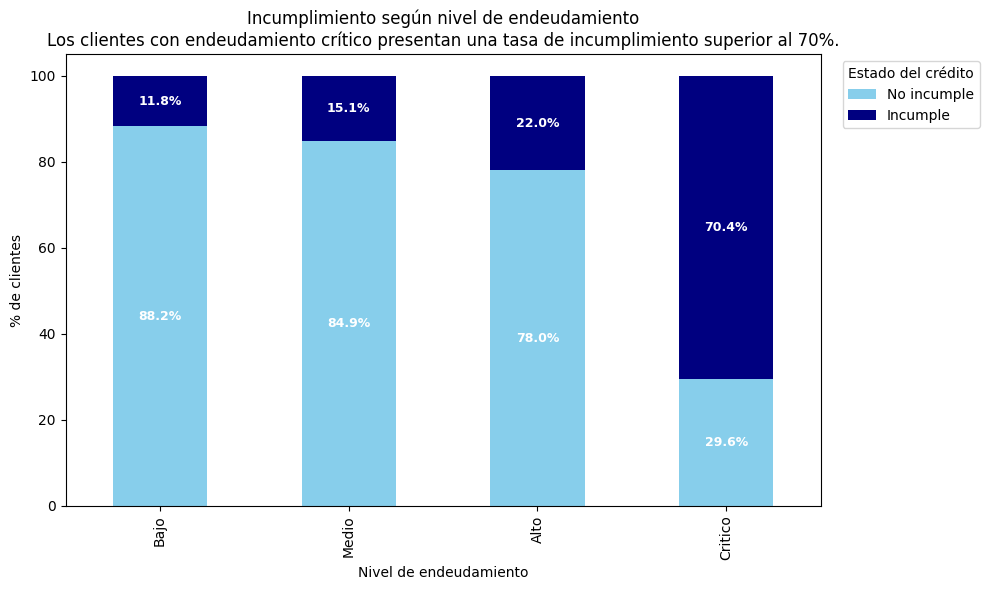

In [38]:
ax = tabla_endeudamiento.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#87CEEB', '#000080']
)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.1f%%',
        label_type='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Incumplimiento según nivel de endeudamiento\n'
    'Los clientes con endeudamiento crítico presentan una tasa de incumplimiento superior al 70%.'
)

plt.xlabel('Nivel de endeudamiento')
plt.ylabel('% de clientes')

# Leyenda fuera de la gráfica
plt.legend(
    ['No incumple', 'Incumple'],
    title='Estado del crédito',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

El nivel de endeudamiento muestra una asociación significativa con el incumplimiento crediticio. A medida que aumenta la proporción del ingreso comprometida por el préstamo, la tasa de incumplimiento se incrementa de forma importante. Particularmente, los clientes clasificados en el nivel de endeudamiento crítico presentan una tasa de incumplimiento del 70,43%, muy superior a la observada en los demás segmentos, lo que sugiere que la carga financiera constituye uno de los principales factores de riesgo dentro de la cartera.

## **Análisis de Correlaciones**

 Con el fin de identificar relaciones lineales entre las variables numéricas y detectar posibles problemas de multicolinealidad, se calculó la matriz de correlaciones

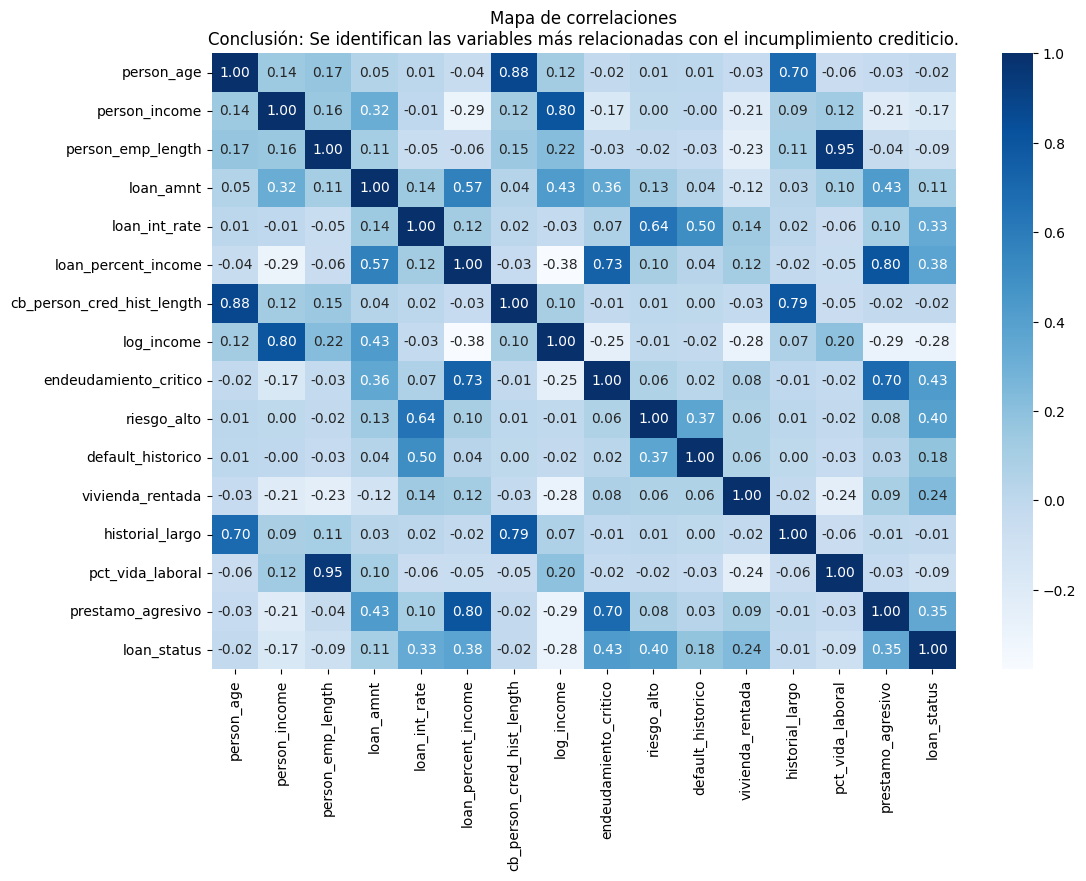

In [33]:
corr = df2[
[
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'log_income',
    'endeudamiento_critico',
    'riesgo_alto',
    'default_historico',
    'vivienda_rentada',
    'historial_largo',
    'pct_vida_laboral',
    'prestamo_agresivo',
    'loan_status'
]
].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title(
    'Mapa de correlaciones\n'
    'Conclusión: Se identifican las variables más relacionadas con el incumplimiento crediticio.'
)

plt.show()

El análisis de correlaciones permitió identificar las variables con mayor asociación al incumplimiento crediticio y detectar posibles problemas de redundancia entre variables. Las variables relacionadas con el endeudamiento y la calidad crediticia presentan las asociaciones más fuertes con la variable objetivo (loan_status), destacándose endeudamiento_critico (0,43), riesgo_alto (0,40), loan_percent_income (0,38) y prestamo_agresivo (0,35). Adicionalmente, se identificaron algunas variables altamente correlacionadas entre sí, como pct_vida_laboral y person_emp_length (0,95), person_age y cb_person_cred_hist_length (0,88), así como person_income y log_income (0,80). Debido a esta redundancia, se optó por conservar las variables más interpretables desde el punto de vista del negocio y eliminar aquellas que aportaban información similar.

In [34]:
df3 = df2.copy()

variables_eliminar = [
    'pct_vida_laboral',
    'log_income',
    'prestamo_agresivo'
]

df3.drop(
    columns=variables_eliminar,
    inplace=True
)

df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32409 entries, 1 to 32580
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32409 non-null  int64   
 1   person_income               32409 non-null  int64   
 2   person_home_ownership       32409 non-null  category
 3   person_emp_length           32409 non-null  float64 
 4   loan_intent                 32409 non-null  category
 5   loan_grade                  32409 non-null  category
 6   loan_amnt                   32409 non-null  int64   
 7   loan_int_rate               32409 non-null  float64 
 8   loan_status                 32409 non-null  int64   
 9   loan_percent_income         32409 non-null  float64 
 10  cb_person_default_on_file   32409 non-null  category
 11  cb_person_cred_hist_length  32409 non-null  int64   
 12  grupo_edad                  32409 non-null  category
 13  grupo_ingreso        

# **CONCLUSIONES**

El análisis exploratorio permitió identificar que el riesgo crediticio está asociado principalmente a variables relacionadas con la calidad crediticia y la capacidad de pago de los solicitantes. Los factores con mayor relación con el incumplimiento fueron el nivel de endeudamiento, la calificación del crédito, la tasa de interés, los antecedentes de incumplimiento y ciertas características patrimoniales como el tipo de vivienda.

Adicionalmente, el proceso de ingeniería de variables permitió construir indicadores derivados que mejoraron la capacidad de interpretación del riesgo, destacándose especialmente endeudamiento_critico y riesgo_alto.

Finalmente, se identificaron y corrigieron inconsistencias presentes en la base de datos, garantizando una mejor calidad de la información para las etapas posteriores de modelado

Integrantes

* Maria Sofia Sepulveda Villa
* Jesica Roman Martinez